## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-June-1st_filled.csv', encoding=enc)

In [5]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,abano terme,veneto,11.79539,45.35783,2023-06-01,2023,6,2023-05-28,45.358184,11.797125,0.352708,0.076309,-0.323681,-0.076309,0.432954,0.129068,-0.379556,-0.129068,0.091163,0.066888,0.064304,0.066888,2023-05-29,45.358184,11.797125,15263.0,14567.0,45.358184,11.797125,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,2023-05-31,45.350207,11.750054,282.321519,2023-05-25,2023-05-18,2023-05-25,2023-05-18,13.810195,25.856935
1,adria,veneto,12.03247,45.07647,2023-06-01,2023,6,2023-05-28,45.075215,12.030687,0.616040,0.327077,-0.530801,-0.327077,0.465901,0.195923,-0.417635,-0.195923,0.119962,0.120671,0.089599,0.120671,2023-05-29,45.075215,12.030687,15145.0,14414.0,45.075215,12.030687,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,2023-05-31,45.050206,12.050055,499.108336,2023-05-25,2023-05-18,2023-05-25,2023-05-18,13.696820,24.735838
2,adria,veneto,12.05787,45.05851,2023-06-01,2023,6,2023-05-28,45.057249,12.057637,0.226331,-0.058133,-0.250691,0.058133,0.308276,0.021064,-0.310412,-0.021064,0.094011,0.120883,0.063419,0.120883,2023-05-29,45.057249,12.057637,15287.0,14559.0,45.057249,12.057637,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,2023-05-31,45.050206,12.050055,499.108336,2023-05-25,2023-05-18,2023-05-25,2023-05-18,13.696820,24.735838
3,adria,veneto,12.05787,45.07647,2023-06-01,2023,6,2023-05-28,45.075215,12.057637,0.517629,0.249955,-0.455300,-0.249955,0.430404,0.175894,-0.398064,-0.175894,0.108025,0.111039,0.069204,0.111039,2023-05-29,45.075215,12.057637,15132.0,14412.0,45.075215,12.057637,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,2023-05-31,45.050206,12.050055,499.108336,2023-05-25,2023-05-18,2023-05-25,2023-05-18,13.696820,24.735838
4,affi,veneto,10.77673,45.55680,2023-06-01,2023,6,2023-05-28,45.555814,10.777538,0.329751,0.043112,-0.324574,-0.043112,0.465339,0.155617,-0.401987,-0.155617,0.055714,0.026191,0.047542,0.026191,2023-05-29,45.555814,10.777538,15025.0,14457.0,45.555814,10.777538,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,2023-05-31,45.550208,10.750049,139.243551,2023-05-25,2023-05-18,2023-05-25,2023-05-18,7.265024,35.054694


In [6]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
cols = dataset.columns
cols

Index(['lau1', 'nuts2', 'x', 'y', 'dt_placement', 'year', 'month',
       'indices_image_date', 'indices_lat', 'indices_lon', 'ndvi_new',
       'ndmi_new', 'ndwi_new', 'ndbi_new', 'ndvi_mean_new', 'ndmi_mean_new',
       'ndwi_mean_new', 'ndbi_mean_new', 'ndvi_std_new', 'ndmi_std_new',
       'ndwi_std_new', 'ndbi_std_new', 'lst_image_date', 'lst_lat', 'lst_lon',
       'lst_day_new', 'lst_night_new', 'monthly_lst_lat', 'monthly_lst_lon',
       'lst_jan_day_mean_new', 'lst_jan_night_mean_new',
       'lst_feb_day_mean_new', 'lst_feb_night_mean_new',
       'lst_mar_day_mean_new', 'lst_mar_night_mean_new',
       'lst_apr_day_mean_new', 'lst_apr_night_mean_new',
       'indices_image_date.1', 'indices_lat.1', 'indices_lon.1',
       'acc_rainfall_jan_new', 'dt_placement_minus_7', 'dt_placement_minus_14',
       'dt_placement_minus_7_avail', 'dt_placement_minus_14_avail',
       'acc_rainfall_1week_new', 'acc_rainfall_2week_new'],
      dtype='object')

In [8]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-06-01,2023,6,0.352708,0.076309,-0.323681,-0.076309,0.432954,0.129068,-0.379556,-0.129068,0.091163,0.066888,0.064304,0.066888,15263.0,14567.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,282.321519,13.810195,25.856935
1,adria,veneto,12.03247,45.07647,2023-06-01,2023,6,0.616040,0.327077,-0.530801,-0.327077,0.465901,0.195923,-0.417635,-0.195923,0.119962,0.120671,0.089599,0.120671,15145.0,14414.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,499.108336,13.696820,24.735838
2,adria,veneto,12.05787,45.05851,2023-06-01,2023,6,0.226331,-0.058133,-0.250691,0.058133,0.308276,0.021064,-0.310412,-0.021064,0.094011,0.120883,0.063419,0.120883,15287.0,14559.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,499.108336,13.696820,24.735838
3,adria,veneto,12.05787,45.07647,2023-06-01,2023,6,0.517629,0.249955,-0.455300,-0.249955,0.430404,0.175894,-0.398064,-0.175894,0.108025,0.111039,0.069204,0.111039,15132.0,14412.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,499.108336,13.696820,24.735838
4,affi,veneto,10.77673,45.55680,2023-06-01,2023,6,0.329751,0.043112,-0.324574,-0.043112,0.465339,0.155617,-0.401987,-0.155617,0.055714,0.026191,0.047542,0.026191,15025.0,14457.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,139.243551,7.265024,35.054694


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-06-01,abano terme,veneto,11.795390,45.357830,2023.0,6.0,0.352708,0.076309,-0.323681,-0.076309,0.432954,0.129068,-0.379556,-0.129068,0.091163,0.066888,0.064304,0.066888,15263.0,14567.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,282.321519,13.810195,25.856935
1,2023-06-01,adria,veneto,12.049403,45.070483,2023.0,6.0,0.453333,0.172967,-0.412264,-0.172967,0.401527,0.130960,-0.375370,-0.130960,0.107333,0.117531,0.074074,0.117531,15188.0,14461.666667,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,499.108336,13.696820,24.735838
2,2023-06-01,affi,veneto,10.776730,45.556800,2023.0,6.0,0.329751,0.043112,-0.324574,-0.043112,0.465339,0.155617,-0.401987,-0.155617,0.055714,0.026191,0.047542,0.026191,15025.0,14457.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,139.243551,7.265024,35.054694
3,2023-06-01,agna,veneto,11.965390,45.175310,2023.0,6.0,0.304736,0.005350,-0.306680,-0.005350,0.411564,0.135998,-0.374753,-0.135998,0.102565,0.107583,0.067687,0.107583,15148.0,14506.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,474.424890,28.850230,44.931100
4,2023-06-01,agordo,veneto,12.059120,46.313990,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-06-01,zevio,veneto,11.127335,45.353970,2023.0,6.0,0.471992,0.069506,-0.413088,-0.069506,0.486138,0.147020,-0.421654,-0.147020,0.056117,0.055916,0.035817,0.055916,15117.0,14491.000000,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,177.378592,21.259294,41.967270
567,2023-06-01,zimella,veneto,11.358050,45.347770,2023.0,6.0,0.465418,0.209673,-0.390656,-0.209673,0.496724,0.235832,-0.423748,-0.235832,0.077245,0.059407,0.063227,0.059407,15290.0,14492.000000,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,195.924798,16.417933,28.753523
568,2023-06-01,zoppe da cadore,veneto,12.178780,46.388350,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
569,2023-06-01,zovencedo,veneto,11.494300,45.437980,2023.0,6.0,0.717541,0.323336,-0.589980,-0.323336,0.716783,0.321607,-0.587985,-0.321607,0.009778,0.013705,0.013384,0.013705,14974.0,14518.000000,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,176.944689,16.120482,18.691807


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

<AxesSubplot:>

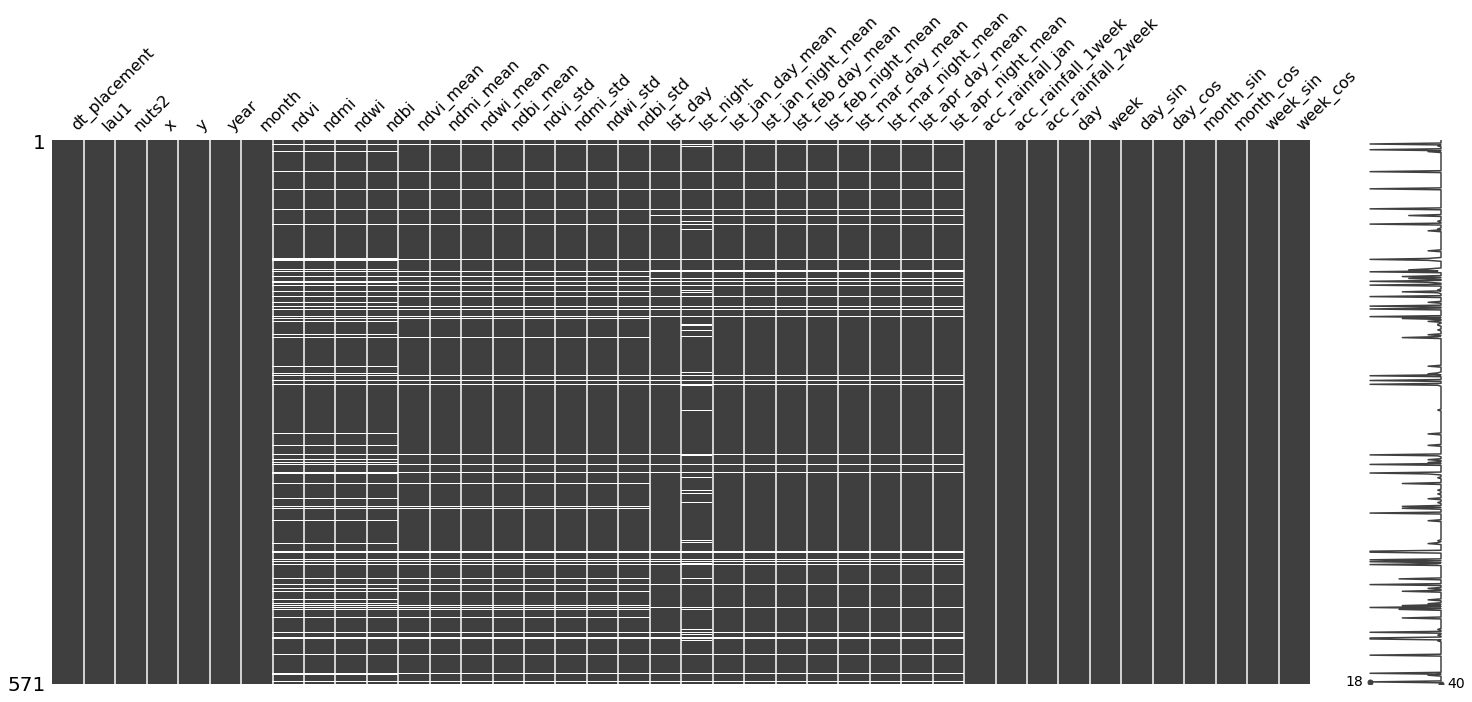

In [15]:
missingno.matrix(dataset)

In [16]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [17]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [18]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [19]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [20]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

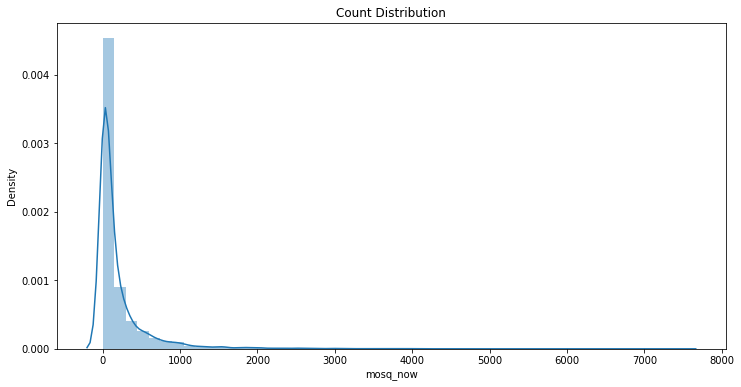

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [22]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

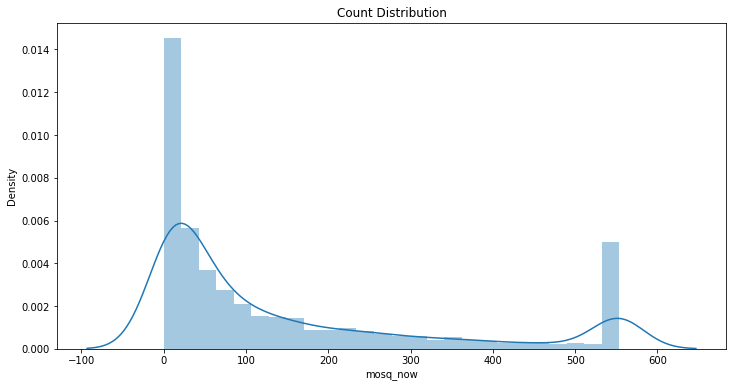

In [23]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

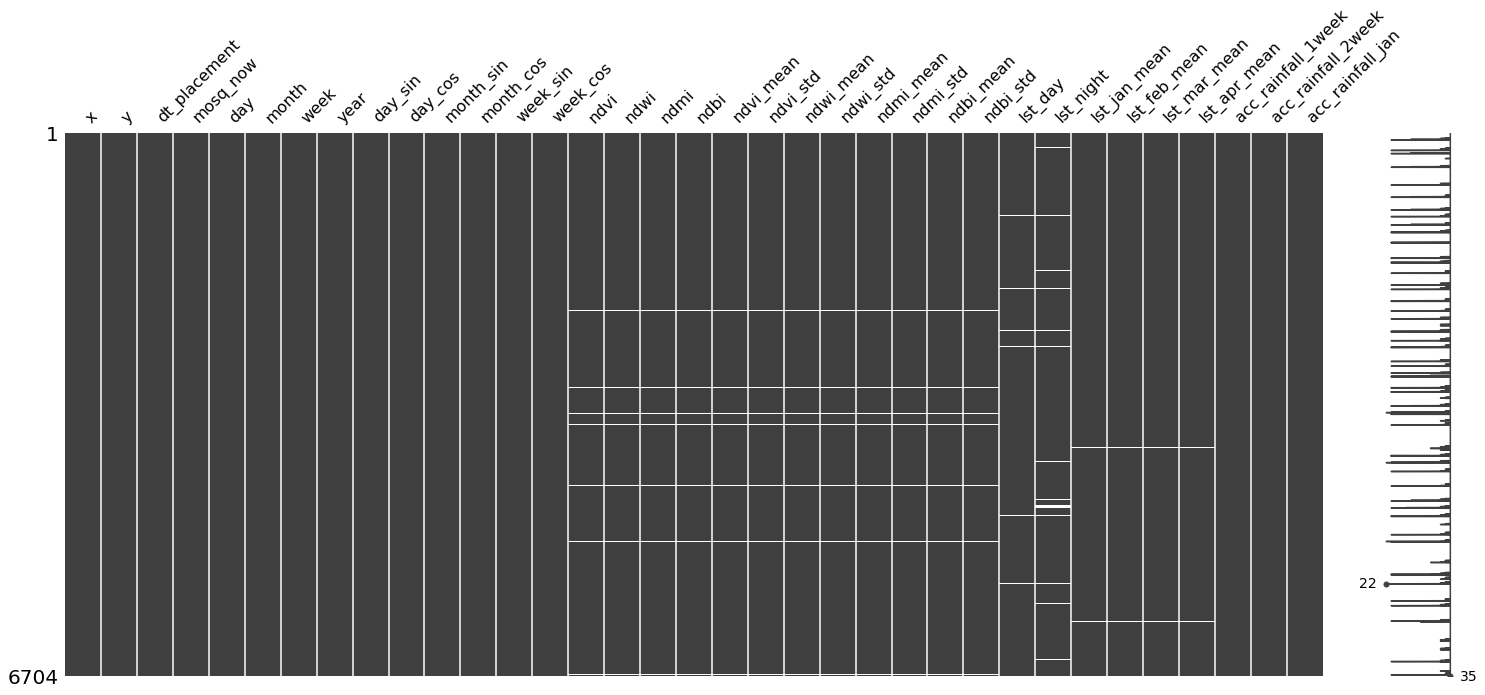

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [26]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

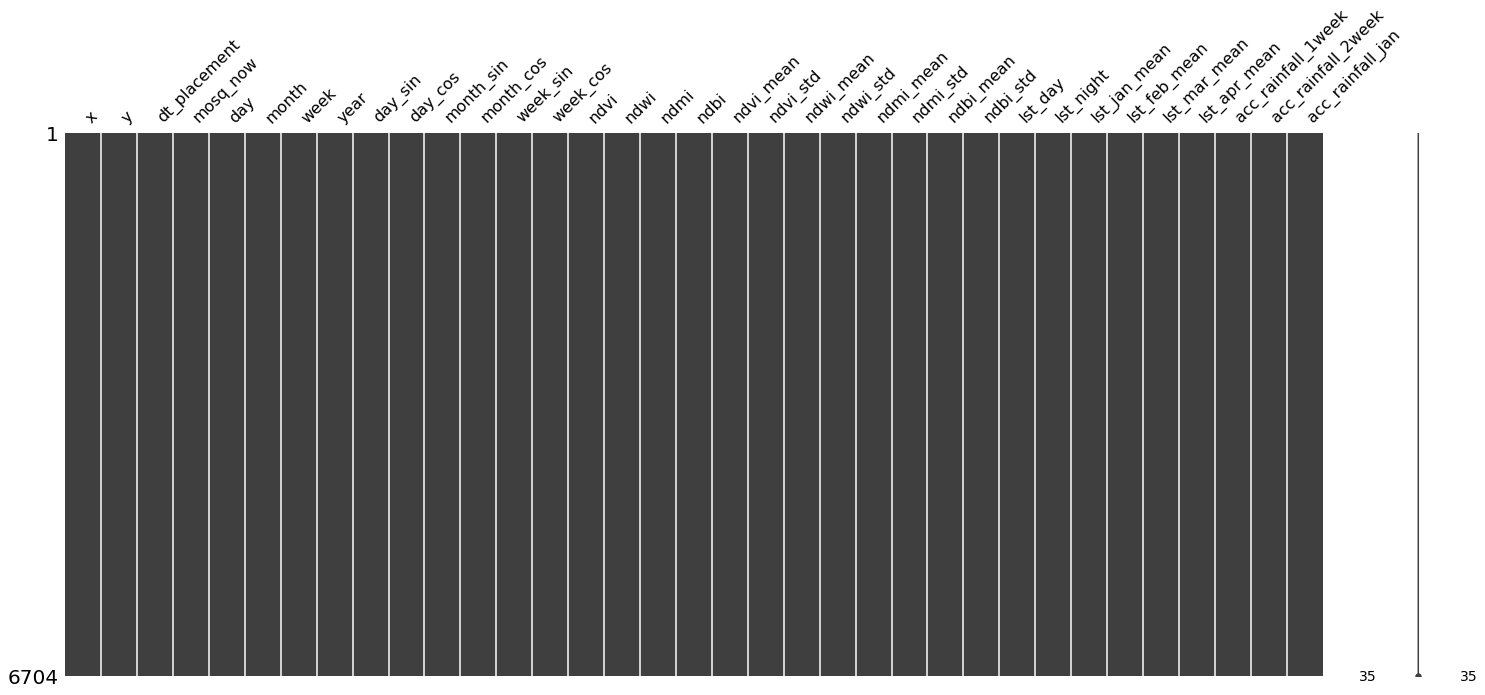

In [27]:
missingno.matrix(mosquito_data_nuts2)

In [28]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [29]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [30]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 8.50214 | Val Loss: 7.17053 | Train Acc: 2.095| Val Acc: 1.816
Epoch 002: | Train Loss: 5.54935 | Val Loss: 6.44120 | Train Acc: 1.562| Val Acc: 1.491
Epoch 003: | Train Loss: 6.05636 | Val Loss: 5.14409 | Train Acc: 1.644| Val Acc: 1.458
Epoch 004: | Train Loss: 5.44034 | Val Loss: 4.60289 | Train Acc: 1.529| Val Acc: 1.261
Epoch 005: | Train Loss: 5.91812 | Val Loss: 5.09103 | Train Acc: 1.579| Val Acc: 1.433
Epoch 006: | Train Loss: 5.19719 | Val Loss: 4.47902 | Train Acc: 1.478| Val Acc: 1.292
Epoch 007: | Train Loss: 5.15677 | Val Loss: 4.08239 | Train Acc: 1.452| Val Acc: 1.165
Epoch 008: | Train Loss: 5.11755 | Val Loss: 4.11902 | Train Acc: 1.450| Val Acc: 1.180
Epoch 009: | Train Loss: 4.88000 | Val Loss: 4.39811 | Train Acc: 1.396| Val Acc: 1.268
Epoch 010: | Train Loss: 4.82806 | Val Loss: 4.20736 | Train Acc: 1.375| Val Acc: 1.214
Epoch 011: | Train Loss: 4.78131 | Val Loss: 4.28575 | Train Acc: 1.382| Val Acc: 1.230
Epoch 012: | Train Loss: 4.63994

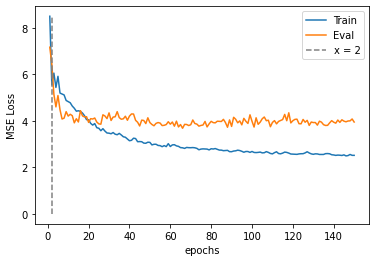

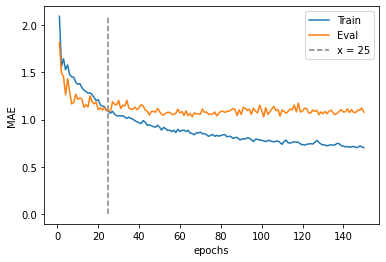

In [31]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
metrics(train, test, threshold=30)

MAE on train set:  79.80964111068057
min prediction: 1
max prediction: 604

MAE on test set:  93.78861077170491
Error ⩽ 30: 30.24 %
min prediction: 1
max prediction: 597


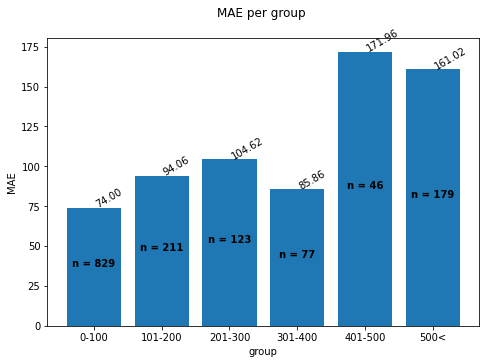

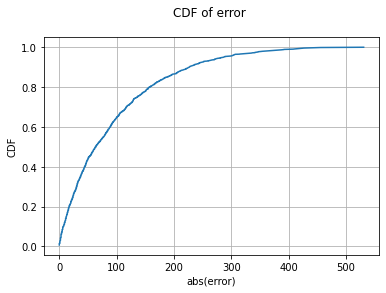

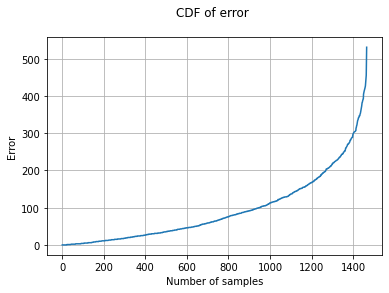

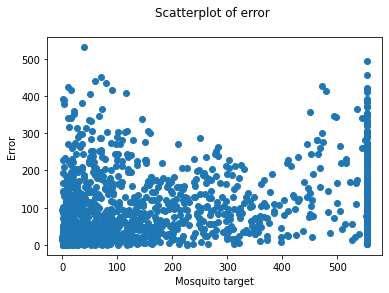

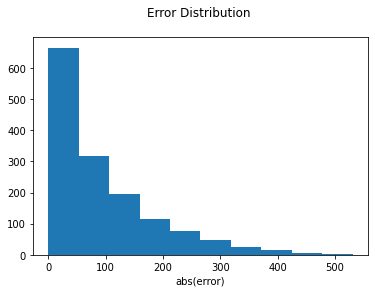

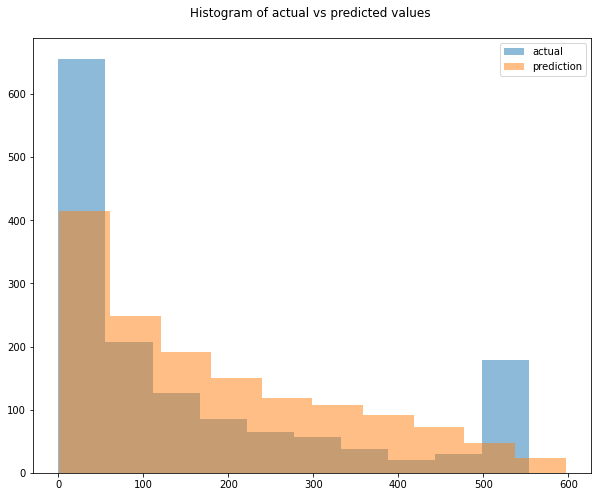

In [33]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.86393 | Val Loss: 0.21928 | Train Acc: 0.859| Val Acc: 0.394
Epoch 002: | Train Loss: 2.69692 | Val Loss: 0.08520 | Train Acc: 0.825| Val Acc: 0.394
Epoch 003: | Train Loss: 2.74577 | Val Loss: 0.43524 | Train Acc: 0.830| Val Acc: 0.394
Epoch 004: | Train Loss: 2.66023 | Val Loss: 0.19085 | Train Acc: 0.821| Val Acc: 0.394
Epoch 005: | Train Loss: 2.69222 | Val Loss: 0.46272 | Train Acc: 0.836| Val Acc: 0.394
Epoch 006: | Train Loss: 2.67457 | Val Loss: 0.75211 | Train Acc: 0.831| Val Acc: 0.394
Epoch 007: | Train Loss: 2.65409 | Val Loss: 0.84632 | Train Acc: 0.823| Val Acc: 1.394
Epoch 008: | Train Loss: 2.63000 | Val Loss: 0.67400 | Train Acc: 0.818| Val Acc: 0.394
Epoch 009: | Train Loss: 2.64741 | Val Loss: 0.56957 | Train Acc: 0.805| Val Acc: 0.394
Epoch 010: | Train Loss: 2.62680 | Val Loss: 0.77893 | Train Acc: 0.800| Val Acc: 0.394
Epoch 011: | Train Loss: 2.62441 | Val Loss: 0.64376 | Train Acc: 0.794| Val Acc: 0.394
Epoch 012: | Train Loss: 2.63260

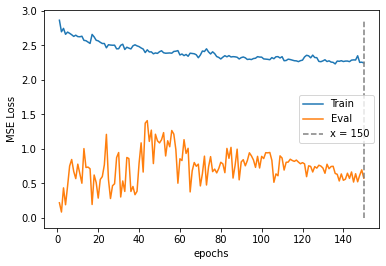

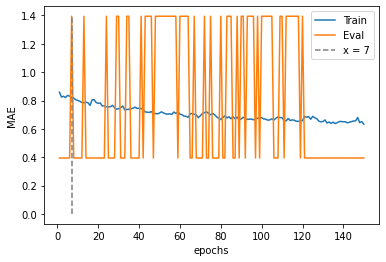

In [34]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [35]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [36]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [37]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [38]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [39]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [40]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

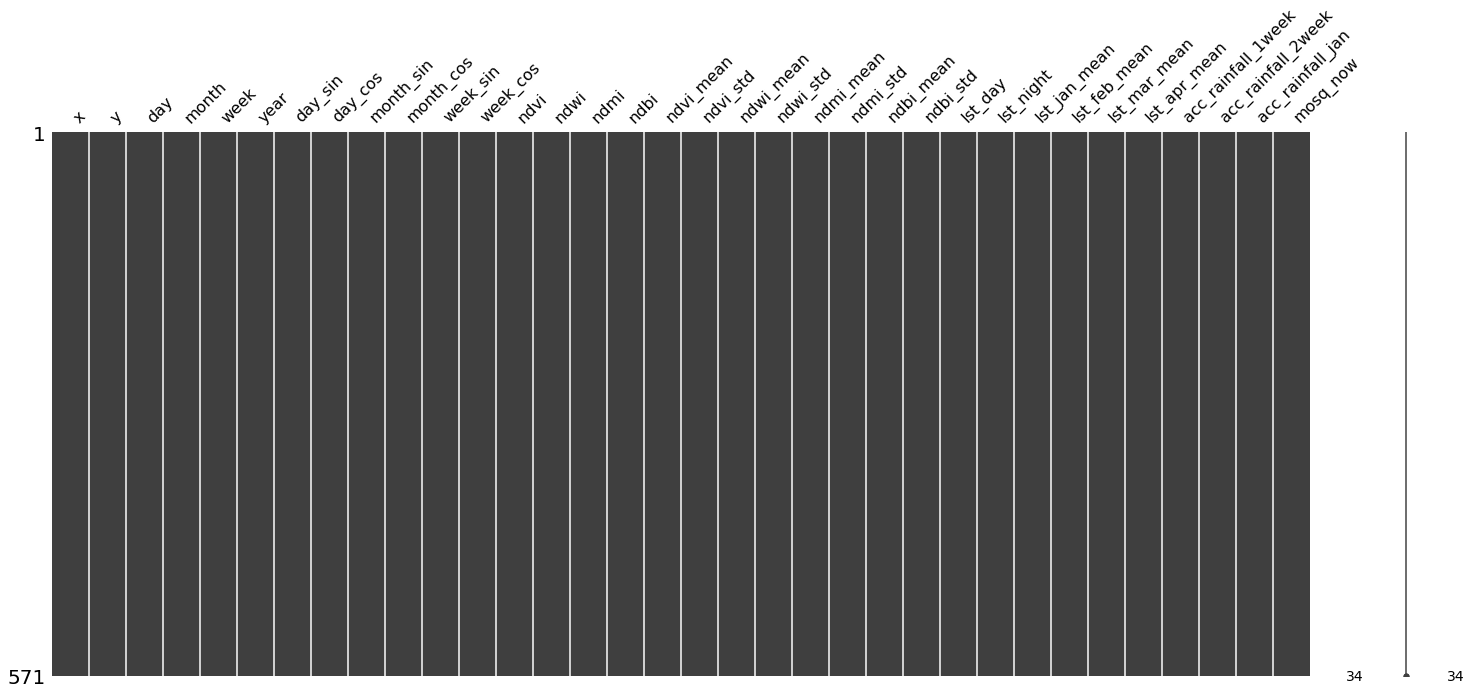

In [41]:
missingno.matrix(dataset_mamoth)

In [42]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [43]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [44]:
predictions = give_predictions(model, dataset_mamoth)

In [45]:
mosqutio_predictions['mosq_pred'] = predictions

In [46]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-06-01,112
1,12.049403,45.070483,2023-06-01,453
2,10.776730,45.556800,2023-06-01,61
3,11.965390,45.175310,2023-06-01,170
4,12.059120,46.313990,2023-06-01,16
...,...,...,...,...
566,11.127335,45.353970,2023-06-01,251
567,11.358050,45.347770,2023-06-01,242
568,12.178780,46.388350,2023-06-01,15
569,11.494300,45.437980,2023-06-01,255


In [47]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-June-1st.csv', index = False)